In [1]:
!pip install pandas numpy matplotlib seaborn plotly scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [3]:
customers = pd.read_csv("customers.csv")

orders = pd.read_csv("orders.csv")

support = pd.read_csv("support_tickets.csv")

web = pd.read_csv("web_events_snapshot.csv")

labels = pd.read_csv("churn_labels.csv")

campaign = pd.read_csv("intervention_history.csv")

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "support": support,
    "web": web,
    "labels": labels,
    "campaign": campaign
}

for name,df in datasets.items():

    print("="*50)
    print(name)
    print(df.shape)
    display(df.head())

customers
(2400, 9)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


orders
(10009, 10)


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


support
(1921, 8)


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


labels
(2400, 4)


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


campaign
(2400, 5)


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [5]:
for name,df in datasets.items():

    print(name)

    display(df.info())

customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB


None

orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB


None

support
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   object 
 1   customer_id       1921 non-null   object 
 2   ticket_date       1921 non-null   object 
 3   issue_type        1921 non-null   object 
 4   support_channel   1921 non-null   object 
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 120.2+ KB


...

None

labels
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     2400 non-null   object
 1   snapshot_date   2400 non-null   object
 2   churn_next_60d  2400 non-null   int64 
 3   split           2400 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.1+ KB


None

campaign
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             2400 non-null   object
 1   snapshot_date           2400 non-null   object
 2   last_campaign_received  2400 non-null   object
 3   last_campaign_cost      2400 non-null   int64 
 4   manual_priority_bucket  2400 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.9+ KB


None

In [6]:
for name,df in datasets.items():

    missing = pd.DataFrame({

        "column":df.columns,
        "missing":df.isna().sum(),
        "pct":round(df.isna().mean()*100,2)

    })

    print(name)

    display(missing.sort_values(
        "missing",
        ascending=False
    ))

customers


,column,missing,pct
loyalty_tier,loyalty_tier,1386,57.75
skin_type,skin_type,401,16.71
customer_id,customer_id,0,0.00
signup_date,signup_date,0,0.00
city_tier,city_tier,0,0.00
acquisition_channel,acquisition_channel,0,0.00
age_group,age_group,0,0.00
preferred_category,preferred_category,0,0.00
marketing_consent,marketing_consent,0,0.00


orders


,column,missing,pct
rating,rating,80,0.8
order_id,order_id,0,0.0
customer_id,customer_id,0,0.0
order_date,order_date,0,0.0
quantity,quantity,0,0.0
category,category,0,0.0
gross_amount,gross_amount,0,0.0
discount_pct,discount_pct,0,0.0
delivery_days,delivery_days,0,0.0
returned,returned,0,0.0


support


...

,column,missing,pct
customer_id,customer_id,0,0.0
snapshot_date,snapshot_date,0,0.0
sessions_30d,sessions_30d,0,0.0
product_views_30d,product_views_30d,0,0.0
cart_adds_30d,cart_adds_30d,0,0.0
wishlist_adds_30d,wishlist_adds_30d,0,0.0
abandoned_carts_30d,abandoned_carts_30d,0,0.0
email_opens_30d,email_opens_30d,0,0.0
campaign_clicks_30d,campaign_clicks_30d,0,0.0
last_visit_days_ago,last_visit_days_ago,0,0.0


labels


,column,missing,pct
customer_id,customer_id,0,0.0
snapshot_date,snapshot_date,0,0.0
churn_next_60d,churn_next_60d,0,0.0
split,split,0,0.0


campaign


,column,missing,pct
customer_id,customer_id,0,0.0
snapshot_date,snapshot_date,0,0.0
last_campaign_received,last_campaign_received,0,0.0
last_campaign_cost,last_campaign_cost,0,0.0
manual_priority_bucket,manual_priority_bucket,0,0.0


In [7]:
dup_orders = orders[
    orders["order_id"].str.contains(
        "_DUP",
        na=False
    )
]

print("Duplicate Like Orders")
print(len(dup_orders))

dup_orders.head()

Duplicate Like Orders
12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


In [8]:
print(customers.customer_id.nunique())

print(
    orders.customer_id.nunique()
)

print(
    support.customer_id.nunique()
)

print(
    web.customer_id.nunique()
)

print(
    labels.customer_id.nunique()
)

print(
    campaign.customer_id.nunique()
)

2400
2400
1247
2400
2400
2400


In [9]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

snapshot = pd.Timestamp(
    "2025-09-30"
)

post_snapshot_orders = orders[
    orders["order_date"] > snapshot
]

print(
    len(post_snapshot_orders)
)

1872


In [10]:
master = (
    customers
    .merge(labels,
           on="customer_id")
)

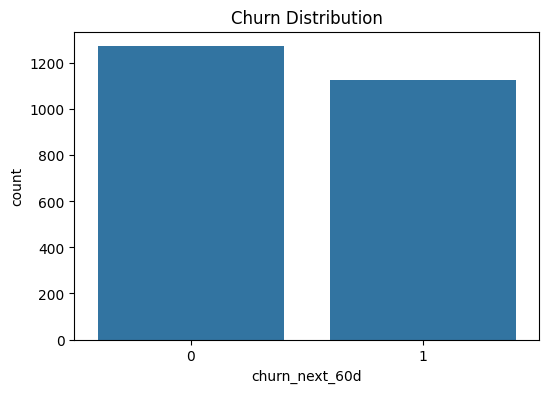

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn_next_60d",
    data=labels
)

plt.title(
    "Churn Distribution"
)

plt.show()

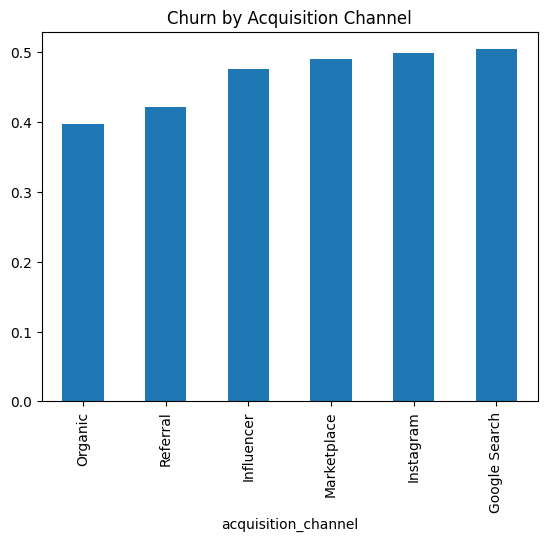

In [12]:
temp = (
    master.groupby(
        "acquisition_channel"
    )["churn_next_60d"]
    .mean()
    .sort_values()
)

temp.plot(
    kind="bar"
)

plt.title(
    "Churn by Acquisition Channel"
)

plt.show()

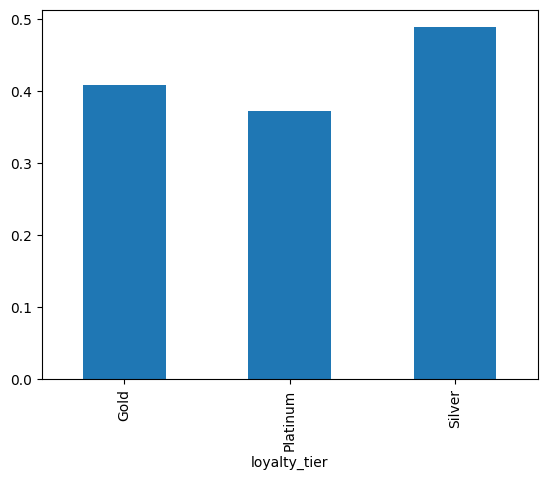

In [13]:
temp = (
    master.groupby(
        "loyalty_tier"
    )["churn_next_60d"]
    .mean()
)

temp.plot(
    kind="bar"
)

plt.show()

In [14]:
pre_orders = orders[
    orders["order_date"]
    <= snapshot
]

In [15]:
last_order = (
    pre_orders
    .groupby("customer_id")
    ["order_date"]
    .max()
)

In [16]:
frequency = (
    pre_orders
    .groupby("customer_id")
    ["order_id"]
    .count()
)

In [17]:
monetary = (
    pre_orders
    .groupby("customer_id")
    ["gross_amount"]
    .sum()
)

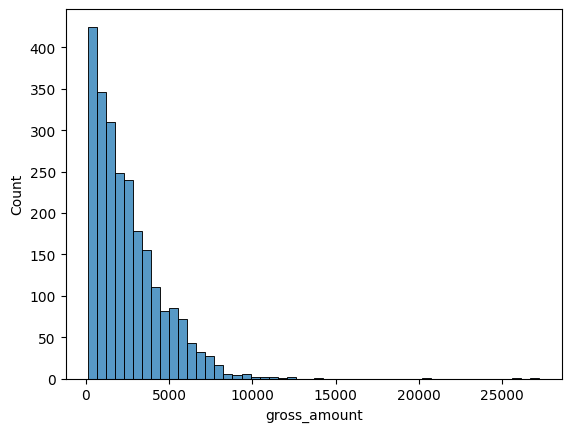

In [18]:
sns.histplot(
    monetary,
    bins=50
)

plt.show()

In [19]:
ticket_count = (
    support
    .groupby("customer_id")
    .size()
)

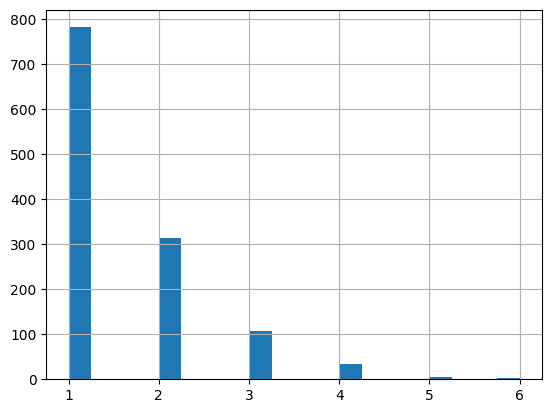

In [20]:
ticket_count.hist(
    bins=20
)

plt.show()

In [21]:
return_rate = (
    pre_orders
    .groupby("customer_id")
    ["returned"]
    .mean()
)

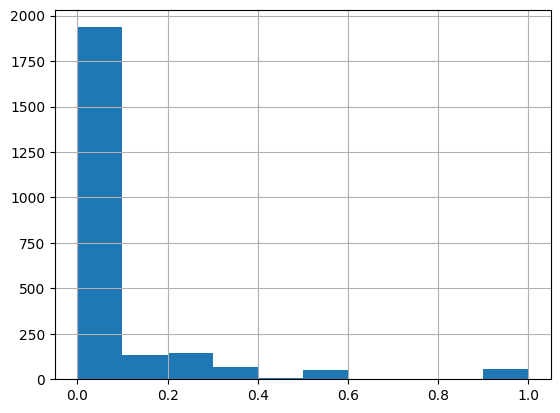

In [22]:
return_rate.hist()

plt.show()

<Axes: xlabel='last_campaign_received'>

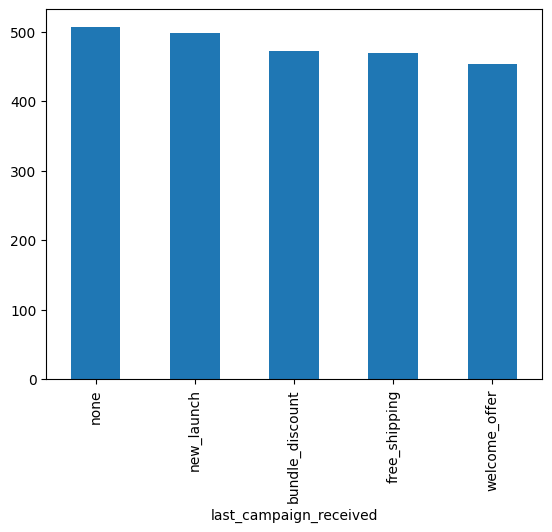

In [23]:
campaign[
    "last_campaign_received"
].value_counts().plot(
    kind="bar"
)

<Axes: >

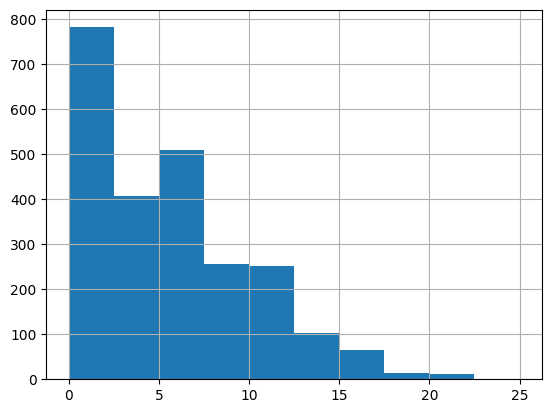

In [24]:
web[
    "sessions_30d"
].hist()

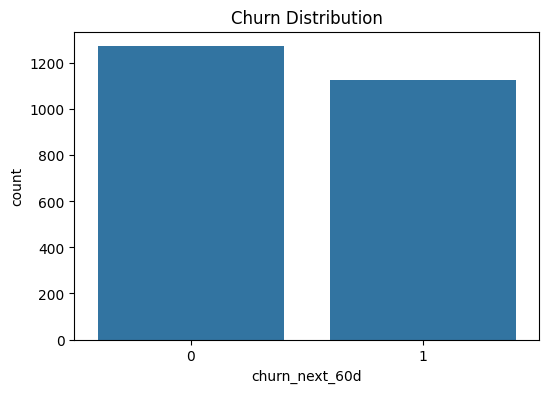

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


In [26]:
import os

plt.figure(figsize=(6,4))

sns.countplot(
    x="churn_next_60d",
    data=labels
)

plt.title(
    "Churn Distribution"
)

# Create the 'outputs' directory if it doesn't exist
os.makedirs("outputs", exist_ok=True)

plt.savefig(
    "outputs/churn_distribution.png"
)

plt.show()

print(
    labels["churn_next_60d"]
    .value_counts(normalize=True)*100
)

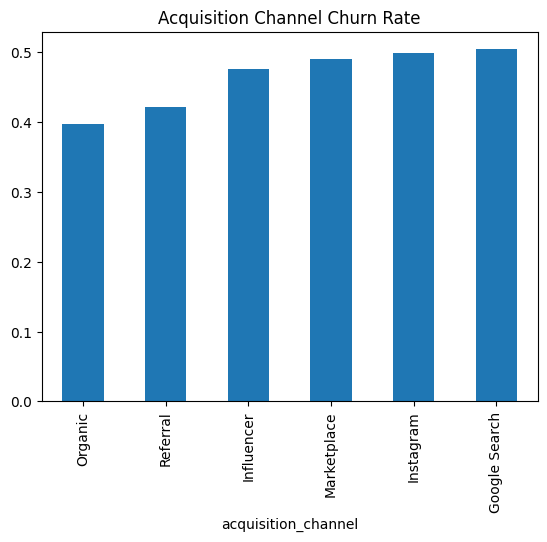

In [27]:
eda = customers.merge(
    labels,
    on="customer_id"
)

channel_churn = (
    eda.groupby(
        "acquisition_channel"
    )["churn_next_60d"]
    .mean()
    .sort_values()
)

channel_churn.plot(
    kind="bar"
)

plt.title(
    "Acquisition Channel Churn Rate"
)

plt.savefig(
    "outputs/acquisition_channel_churn.png"
)

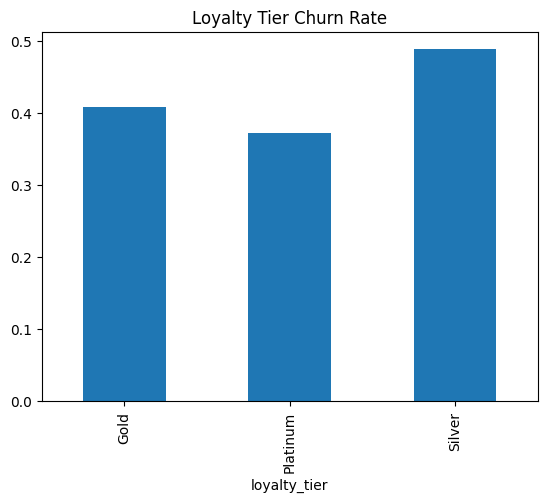

In [28]:
tier_churn = (
    eda.groupby(
        "loyalty_tier"
    )["churn_next_60d"]
    .mean()
)

tier_churn.plot(
    kind="bar"
)

plt.title(
    "Loyalty Tier Churn Rate"
)

plt.savefig(
    "outputs/loyalty_tier_churn.png"
)

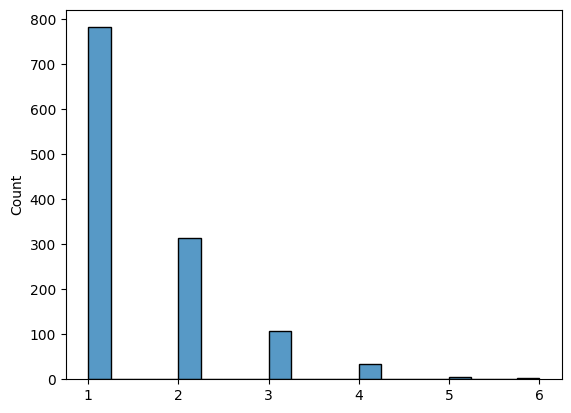

In [29]:
ticket_count = (
    support
    .groupby("customer_id")
    .size()
)

sns.histplot(
    ticket_count,
    bins=20
)

plt.savefig(
    "outputs/ticket_distribution.png"
)

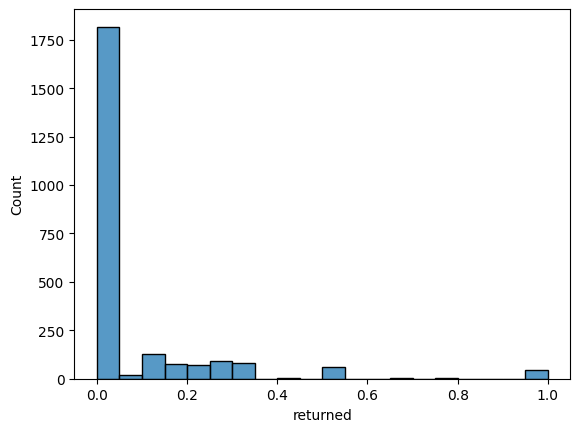

In [30]:
return_rate = (
    orders
    .groupby("customer_id")
    ["returned"]
    .mean()
)

sns.histplot(
    return_rate,
    bins=20
)

plt.savefig(
    "outputs/return_rate_distribution.png"
)